# Attention-Based Patient Representation from Cell Embeddings
> Inspired by the **Pascient** paper — aggregates cell-level embeddings into a single patient-level vector using learned attention weights.

### Pipeline Overview
```
Cell Embeddings (N × d_h)
        ↓  Attention MLP
  Per-cell scores (N,)
        ↓  Softmax 
  Attention weights (N,)
        ↓  Weighted sum
  Patient embedding (d_h,)
        ↓  Classifier MLP
  Prediction (num_classes,)

Step 1: Attention MLP scores cells          (no labels yet)
Step 2: Weighted sum → patient embedding    (no labels yet)
Step 3: Classifier predicts disease/healthy (no labels yet)
Step 4: Compare prediction vs TRUE LABEL    ← labels enter here
Step 5: Compute how wrong we were (loss)
Step 6: Backpropagate error signal BACKWARDS through entire network
Step 7: Update ALL weights including Attention MLP
```

## Block 1 — Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

# Use GPU if available, otherwise fall back to CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device:    {DEVICE}")

PyTorch version: 2.8.0
CUDA available:  False
Using device:    cpu


In [2]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ["PYTHONHASHSEED"]       = str(seed)
    print(f"Random seed set to {seed} ✓")

set_seed(42)

Random seed set to 42 ✓


## Block 2 — Hyperparameters
Centralise all settings here so you only need to edit one cell.

In [3]:
# ── Data ──────────────────────────────────────────────────────
D_H           = 512   # embedding dimension from X_scVI
NUM_CLASSES   = 2     # normal=0, Crohn disease=1

# ── Training ──────────────────────────────────────────────────
BATCH_SIZE    = 8
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 10
RANDOM_SEED   = 42

# ── Paths ──────────────────────────────────────────────────────
DISCOVERY_DIR          = "data/discovery/"
VALIDATION_DIR         = "data/validation/"
DISCOVERY_LABELS_PATH  = "data/discovery_labels.npy"
VALIDATION_LABELS_PATH = "data/validation_labels.npy"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {DEVICE}")

Using device : cpu


## Block 3 — Attention Pooling Model

Two sub-networks inside the model:
- **`self.attn`** — small MLP that scores each cell's importance
- **`self.classifier`** — maps the pooled patient vector to class logits

> 💡 `Tanh` (not ReLU) is used in the attention branch, following Ilse et al. 2018, because it allows negative pre-softmax scores, giving richer expressivity.

In [4]:
class AttentionPoolingModel(nn.Module):
    """
    Aggregates a variable number of cell embeddings into one
    patient-level embedding via learned softmax attention,
    then classifies the patient.

    Args:
        d_h         : Dimensionality of input cell embeddings
        num_classes : Number of output classes
    """

    def __init__(self, d_h: int, num_classes: int):
        super().__init__()

        # ── Attention network ──────────────────────────────────────────
        # Input : (B, N, d_h)
        # Output: (B, N, 1) → scalar importance score per cell
        self.attn = nn.Sequential(
            nn.Linear(d_h, d_h),  # Mix features across the latent space
            nn.Tanh(),            # Bounded non-linearity: output in (-1, +1)
            nn.Linear(d_h, 1)     # Collapse to a single score per cell
        )

        # ── Classifier ────────────────────────────────────────────────
        # Input : (B, d_h)         — pooled patient embedding
        # Output: (B, num_classes) — raw logits for CrossEntropyLoss
        self.classifier = nn.Sequential(
            nn.Linear(d_h, d_h),
            nn.ReLU(),
            nn.Dropout(0.0),
            nn.Linear(d_h, num_classes)
        )

    def forward(self, Z, mask=None):
        """
        Args:
            Z    : (B, N, d_h) — batch of padded cell embedding matrices
            mask : (B, N) bool  — True = real cell, False = padding

        Returns:
            preds       : (B, num_classes) — classification logits
            patient_emb : (B, d_h)         — pooled patient embedding
            weights     : (B, N)           — per-cell attention weights (sum to 1)
        """

        # Step 1: Score every cell
        # attn maps (B, N, d_h) → (B, N, 1); squeeze removes last dim → (B, N)
        scores = self.attn(Z).squeeze(-1)

        # Step 2: Zero out padded positions
        # Setting padding scores to -1e9 makes softmax assign ~0 weight there
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)

        # Step 3: Convert raw scores → probability weights
        # softmax over cell dimension → weights sum to 1 per patient
        weights = F.softmax(scores, dim=1)  # (B, N)

        # Step 4: Weighted sum → single patient embedding
        # weights.unsqueeze(-1) → (B, N, 1); broadcast-multiply with Z (B, N, d_h)
        patient_emb = torch.sum(
            Z * weights.unsqueeze(-1), dim=1
        )  # → (B, d_h)

        # Step 5: Classify the patient
        preds = self.classifier(patient_emb)  # (B, num_classes)

        return preds, patient_emb, weights

## Block 4 — Dataset

Each item represents **one patient** and holds:
| Key | Shape | Description |
|-----|-------|-------------|
| `Z` | `(num_cells, d_h)` | Cell embedding matrix |
| `mask` | `(num_cells,)` | Boolean — `True` for real cells |
| `label` | scalar | Integer class label |

> 🔁 **To use your own data**: replace the synthetic generation loop with real embeddings loaded from `.h5ad` / `.npy` / AnnData, and set `label` from your metadata.

In [5]:
class PatientDataset(Dataset):
    """
    Wraps a list of patient dicts into a PyTorch Dataset.

    Each dict must contain:
        'Z'     : FloatTensor of shape (num_cells, d_h)
        'mask'  : BoolTensor  of shape (num_cells,)
        'label' : int
    """

    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        # Total number of patients
        return len(self.data)

    def __getitem__(self, idx):
        # Return the three tensors for one patient
        item = self.data[idx]
        return item["Z"], item["mask"], item["label"]

## Block 5 — Collate Function

Patients have **different numbers of cells**, so we can't stack them into a tensor naively.
This function pads all patients in a batch to the length of the longest one.

```
Patient A: 80 cells  ──┐
Patient B: 55 cells  ──┼──▶  padded to (B, 112, d_h)  +  mask
Patient C: 112 cells ──┘
```

In [6]:
def collate_fn(batch):
    """
    Pads a batch of variable-length patients to a uniform tensor.

    Args:
        batch : list of (Z, mask, label) tuples from PatientDataset

    Returns:
        Z_padded    : (B, max_cells, d_h)  — zero-padded cell embeddings
        mask_padded : (B, max_cells) bool  — True where cells are real
        labels      : (B,)                 — class labels
    """
    Z_list, mask_list, labels = zip(*batch)

    # Find the longest patient in this batch to set the padding target
    max_cells = max(z.shape[0] for z in Z_list)
    d_h = Z_list[0].shape[1]
    B   = len(Z_list)

    # Allocate zero-filled tensors; padding positions stay as zeros
    Z_padded    = torch.zeros(B, max_cells, d_h)
    mask_padded = torch.zeros(B, max_cells, dtype=torch.bool)

    # Fill in the real data for each patient up to its actual cell count
    for i, (Z, mask) in enumerate(zip(Z_list, mask_list)):
        n = Z.shape[0]           # actual number of cells for this patient
        Z_padded[i, :n]    = Z
        mask_padded[i, :n] = mask

    labels = torch.tensor(labels)

    return Z_padded, mask_padded, labels

## Block 6 —  Load test Discovery & Validation Data

In [7]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def load_patient_folder(folder_path, labels_path):
    """
    Loads per-patient .npy files and labels.
    Each .npy: (num_cells, 512)
    Returns list of dicts: Z, mask, label
    """
    data_list     = []
    labels        = np.load(labels_path)
    patient_files = sorted([
        f for f in os.listdir(folder_path)
        if f.endswith(".npy")
    ])

    assert len(patient_files) == len(labels), \
        f"Mismatch: {len(patient_files)} files, {len(labels)} labels"

    for i, fname in enumerate(patient_files):
        Z     = torch.tensor(
                    np.load(os.path.join(folder_path, fname)),
                    dtype=torch.float32
                )
        mask  = torch.ones(Z.shape[0], dtype=torch.bool)
        label = int(labels[i])
        data_list.append({"Z": Z, "mask": mask, "label": label})

    return data_list

# ── Load splits ────────────────────────────────────────────────
discovery_list  = load_patient_folder(DISCOVERY_DIR,  DISCOVERY_LABELS_PATH)
validation_list = load_patient_folder(VALIDATION_DIR, VALIDATION_LABELS_PATH)

discovery_dataset  = PatientDataset(discovery_list)
validation_dataset = PatientDataset(validation_list)

# ── DataLoaders with fixed seed ────────────────────────────────
g = torch.Generator()
g.manual_seed(RANDOM_SEED)

discovery_loader = DataLoader(
    discovery_dataset,
    batch_size     = BATCH_SIZE,
    shuffle        = True,
    collate_fn     = collate_fn,
    worker_init_fn = seed_worker,
    generator      = g
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size     = BATCH_SIZE,
    shuffle        = False,        # never shuffle validation
    collate_fn     = collate_fn,
    worker_init_fn = seed_worker,
    generator      = g
)

# ── Sanity check ───────────────────────────────────────────────
print(f"Discovery  patients : {len(discovery_dataset)}")
print(f"Validation patients : {len(validation_dataset)}")

Z_s, mask_s, labels_s = next(iter(discovery_loader))
print(f"\nSample discovery batch —")
print(f"  Z shape      : {Z_s.shape}   (B, max_cells, d_h)")
print(f"  mask shape   : {mask_s.shape}")
print(f"  labels       : {labels_s}")
print(f"  Embedding dim: {Z_s.shape[2]}")

Discovery  patients : 40
Validation patients : 10

Sample discovery batch —
  Z shape      : torch.Size([8, 21053, 512])   (B, max_cells, d_h)
  mask shape   : torch.Size([8, 21053])
  labels       : tensor([0, 1, 1, 0, 0, 1, 1, 1])
  Embedding dim: 512


# Block 7 — Initialise model, optimizer, weighted loss

In [8]:
set_seed(RANDOM_SEED)   # re-set before model init for reproducible weights

# ── Model ──────────────────────────────────────────────────────
model = AttentionPoolingModel(
    d_h         = D_H,
    num_classes = NUM_CLASSES
).to(DEVICE)

# ── Optimizer ──────────────────────────────────────────────────
optimizer = torch.optim.Adam(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = 1e-4 # L2 Normalisation
)

# ── Weighted loss for imbalanced data ──────────────────────────
# 86 Normal vs 30 Crohn disease → Crohn gets ~3x higher penalty
disc_labels    = np.load(DISCOVERY_LABELS_PATH)
n_normal       = (disc_labels == 0).sum()
n_disease      = (disc_labels == 1).sum()
n_total        = len(disc_labels)

weight_normal  = n_total / (2 * n_normal)
weight_disease = n_total / (2 * n_disease)

class_weights  = torch.tensor(
    [weight_normal, weight_disease],
    dtype = torch.float32
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── Summary ────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model d_h            : {D_H}")
print(f"Trainable parameters : {total_params:,}")
print(f"\nClass weights:")
print(f"  Normal        (0) : {weight_normal:.3f}")
print(f"  Crohn disease (1) : {weight_disease:.3f}")

Random seed set to 42 ✓


Model d_h            : 512
Trainable parameters : 526,851

Class weights:
  Normal        (0) : 1.818
  Crohn disease (1) : 0.690


# Block 8 — Training + validation loop

In [16]:
import pandas as pd
from sklearn.metrics import roc_auc_score

LABEL_NAMES = {0: "Normal", 1: "Crohn disease"}
train_losses   = []
val_losses     = []
val_accuracies = []
best_val_acc   = 0.0
best_epoch     = 1

# ── Build donor lookup from validation filenames ───────────────
val_files      = sorted([
    f for f in os.listdir(VALIDATION_DIR) if f.endswith(".npy")
])
val_labels_arr = np.load(VALIDATION_LABELS_PATH)

donor_lookup = {
    i: {
        "donor_id"   : f.replace("_embeddings.npy", ""),
        "true_label" : LABEL_NAMES[int(val_labels_arr[i])]
    }
    for i, f in enumerate(val_files)
}
print(f"Donor lookup built for {len(donor_lookup)} validation donors ✓")

# ── Training + validation loop ─────────────────────────────────
for epoch in range(NUM_EPOCHS):

    # ── Training ───────────────────────────────────────────────
    model.train()
    total_train_loss = 0.0
    train_correct    = 0
    train_total      = 0

    for Z, mask, labels in discovery_loader:
        Z, mask, labels = (Z.to(DEVICE),
                           mask.to(DEVICE),
                           labels.to(DEVICE))
        Z = F.normalize(Z, dim=-1)

        preds, _, _  = model(Z, mask)
        loss         = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_correct    += (preds.argmax(1) == labels).sum().item()
        train_total      += labels.size(0)

    avg_train_loss = total_train_loss / len(discovery_loader)
    train_acc      = train_correct / train_total * 100

    # ── Validation ─────────────────────────────────────────────
    model.eval()
    total_val_loss = 0.0
    val_correct    = 0
    val_total      = 0

    epoch_preds  = []
    epoch_labels = []
    epoch_probs  = []

    with torch.no_grad():
        for Z, mask, labels in validation_loader:
            Z, mask, labels = (Z.to(DEVICE),
                               mask.to(DEVICE),
                               labels.to(DEVICE))
            Z = F.normalize(Z, dim=-1)

            preds, _, _ = model(Z, mask)
            probs       = torch.softmax(preds, dim=1)
            loss        = criterion(preds, labels)

            total_val_loss += loss.item()
            val_correct    += (preds.argmax(1) == labels).sum().item()
            val_total      += labels.size(0)

            epoch_preds.append(preds.argmax(1).cpu())
            epoch_labels.append(labels.cpu())
            epoch_probs.append(probs.cpu())

    avg_val_loss    = total_val_loss / len(validation_loader)
    val_acc         = val_correct / val_total * 100

    epoch_preds_np  = torch.cat(epoch_preds).numpy()
    epoch_labels_np = torch.cat(epoch_labels).numpy()
    epoch_probs_np  = torch.cat(epoch_probs).numpy()

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    # ── Save best model by accuracy ────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1

        torch.save(model.state_dict(), "best_model.pt")

        # ── Build donor results table at this best epoch ───────
        def get_outcome(true, pred):
            if true == 0 and pred == 0: return "TN — Correct Normal"
            if true == 1 and pred == 1: return "TP — Correct Crohn"
            if true == 0 and pred == 1: return "FP — Normal called Crohn"
            return                             "FN — Crohn called Normal"

        best_results_df = pd.DataFrame([
            {
                "donor_id"        : donor_lookup[i]["donor_id"],
                "true_label"      : donor_lookup[i]["true_label"],
                "predicted_label" : LABEL_NAMES[int(epoch_preds_np[i])],
                "prob_normal"     : round(float(epoch_probs_np[i, 0]), 3),
                "prob_crohn"      : round(float(epoch_probs_np[i, 1]), 3),
                "correct"         : bool(epoch_preds_np[i] == epoch_labels_np[i]),
                "outcome"         : get_outcome(
                                        int(epoch_labels_np[i]),
                                        int(epoch_preds_np[i])
                                    ),
            }
            for i in range(len(epoch_preds_np))
        ])

        print(f"  ✓ Best model saved at epoch {epoch+1} "
              f"(Val Acc: {val_acc:.1f}%)")

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}]  "
          f"Train Loss: {avg_train_loss:.4f}  "
          f"Train Acc: {train_acc:.1f}%  "
          f"Val Loss: {avg_val_loss:.4f}  "
          f"Val Acc: {val_acc:.1f}%")

# ── Final summary ──────────────────────────────────────────────
print(f"\nBest validation accuracy : {best_val_acc:.1f}%")
print(f"Best epoch selected      : {best_epoch} / {NUM_EPOCHS}")
print(f"Model saved to           : best_model.pt")
print("Training complete.")

# ── Print donor results table from best epoch ──────────────────
best_results_df = best_results_df.sort_values(
    ["outcome", "prob_crohn"],
    ascending=[True, False]
).reset_index(drop=True)

print("\n" + "=" * 85)
print(f"  DONOR RESULTS AT BEST EPOCH ({best_epoch})")
print("=" * 85)
print(best_results_df.to_string(index=False))

print("\n" + "=" * 85)
print("  OUTCOME SUMMARY")
print("=" * 85)
print(best_results_df["outcome"].value_counts().to_string())

# ── Save to CSV ────────────────────────────────────────────────
best_results_df.to_csv("best_epoch_donor_results.csv", index=False)
print(f"\nSaved → best_epoch_donor_results.csv ✓")

Donor lookup built for 10 validation donors ✓


  ✓ Best model saved at epoch 1 (Val Acc: 90.0%)
Epoch [01/10]  Train Loss: 0.4951  Train Acc: 85.0%  Val Loss: 0.4501  Val Acc: 90.0%


Epoch [02/10]  Train Loss: 0.4525  Train Acc: 85.0%  Val Loss: 0.4371  Val Acc: 90.0%


  ✓ Best model saved at epoch 3 (Val Acc: 100.0%)
Epoch [03/10]  Train Loss: 0.4032  Train Acc: 85.0%  Val Loss: 0.3667  Val Acc: 100.0%


Epoch [04/10]  Train Loss: 0.3742  Train Acc: 85.0%  Val Loss: 0.3385  Val Acc: 100.0%


...

Epoch [06/10]  Train Loss: 0.3099  Train Acc: 87.5%  Val Loss: 0.2372  Val Acc: 90.0%


Epoch [07/10]  Train Loss: 0.2690  Train Acc: 90.0%  Val Loss: 0.2821  Val Acc: 100.0%


Epoch [08/10]  Train Loss: 0.2518  Train Acc: 87.5%  Val Loss: 0.2231  Val Acc: 90.0%


Epoch [09/10]  Train Loss: 0.2253  Train Acc: 90.0%  Val Loss: 0.2322  Val Acc: 100.0%


Epoch [10/10]  Train Loss: 0.1901  Train Acc: 90.0%  Val Loss: 0.2000  Val Acc: 90.0%

Best validation accuracy : 100.0%
Best epoch selected      : 3 / 10
Model saved to           : best_model.pt
Training complete.

  DONOR RESULTS AT BEST EPOCH (3)
donor_id    true_label predicted_label  prob_normal  prob_crohn  correct             outcome
     N13        Normal          Normal        0.536       0.464     True TN — Correct Normal
  197396        Normal          Normal        0.654       0.346     True TN — Correct Normal
     N20        Normal          Normal        0.817       0.183     True TN — Correct Normal
  172428 Crohn disease   Crohn disease        0.163       0.837     True  TP — Correct Crohn
  148519 Crohn disease   Crohn disease        0.177       0.823     True  TP — Correct Crohn
  125985 Crohn disease   Crohn disease        0.196       0.804     True  TP — Correct Crohn
  104689 Crohn disease   Crohn disease        0.203       0.797     True  TP — Correct Crohn
  1950

# Block 8b — Validation breakdown

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

# ── Load best saved model for evaluation ──────────────────────
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for Z, mask, labels in validation_loader:
        Z, mask, labels = (Z.to(DEVICE),
                           mask.to(DEVICE),
                           labels.to(DEVICE))
        Z = F.normalize(Z, dim=-1)

        preds, _, _ = model(Z, mask)
        probs       = torch.softmax(preds, dim=1)

        all_preds.append(preds.argmax(1).cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_probs  = torch.cat(all_probs).numpy()

cm         = confusion_matrix(all_labels, all_preds)
TN, FP, FN, TP = cm.ravel()

print("=" * 50)
print("       VALIDATION RESULTS")
print("=" * 50)
print(f"  Total patients                : {len(all_labels)}")
print(f"  Total Normal       (label=0)  : {(all_labels==0).sum()}")
print(f"  Total Crohn disease(label=1)  : {(all_labels==1).sum()}")
print("-" * 50)
print(f"  Correctly identified Normal   : {TN}  (True Negatives)")
print(f"  Correctly identified Crohn    : {TP}  (True Positives)")
print(f"  Normal wrongly called Crohn   : {FP}  (False Positives)")
print(f"  Crohn wrongly called Normal   : {FN}  (False Negatives)")
print("=" * 50)
print(f"  Overall accuracy              : {(TP+TN)/len(all_labels)*100:.1f}%")
print(f"  Sensitivity (Crohn recall)    : {TP/(TP+FN)*100:.1f}%")
print(f"  Specificity (Normal recall)   : {TN/(TN+FP)*100:.1f}%")
print("=" * 50)
print(classification_report(
    all_labels, all_preds,
    target_names=["Normal", "Crohn disease"]
))

       VALIDATION RESULTS
  Total patients                : 10
  Total Normal       (label=0)  : 3
  Total Crohn disease(label=1)  : 7
--------------------------------------------------
  Correctly identified Normal   : 3  (True Negatives)
  Correctly identified Crohn    : 7  (True Positives)
  Normal wrongly called Crohn   : 0  (False Positives)
  Crohn wrongly called Normal   : 0  (False Negatives)
  Overall accuracy              : 100.0%
  Sensitivity (Crohn recall)    : 100.0%
  Specificity (Normal recall)   : 100.0%
               precision    recall  f1-score   support

       Normal       1.00      1.00      1.00         3
Crohn disease       1.00      1.00      1.00         7

     accuracy                           1.00        10
    macro avg       1.00      1.00      1.00        10
 weighted avg       1.00      1.00      1.00        10



# Block 9 — Plot training curves

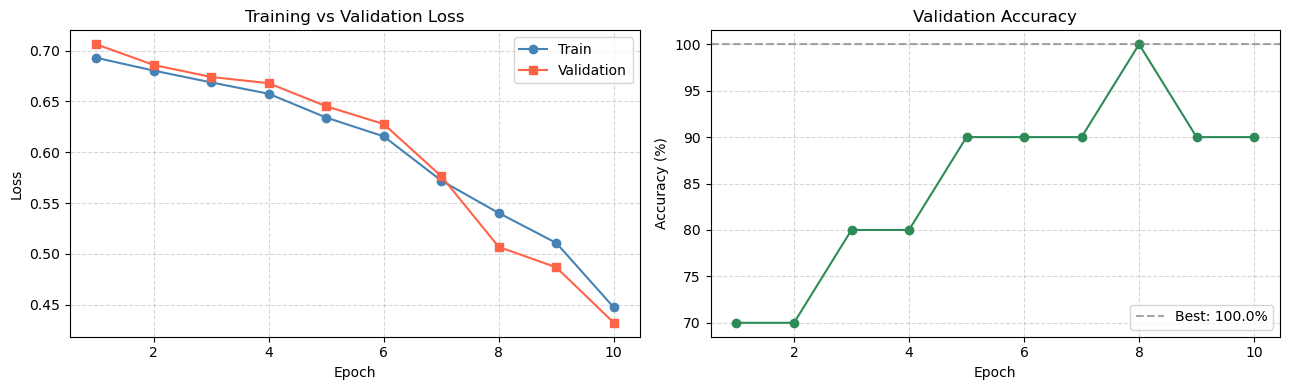

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Loss curve ────────────────────────────────────────────────
axes[0].plot(range(1, NUM_EPOCHS+1), train_losses,
             marker='o', label='Train', color='steelblue')
axes[0].plot(range(1, NUM_EPOCHS+1), val_losses,
             marker='s', label='Validation', color='tomato')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# ── Accuracy curve ────────────────────────────────────────────
axes[1].plot(range(1, NUM_EPOCHS+1), val_accuracies,
             marker='o', color='seagreen')
axes[1].axhline(y=best_val_acc, linestyle='--',
                color='gray', alpha=0.7,
                label=f'Best: {best_val_acc:.1f}%')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Validation Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Complete code block — all metrics together

In [12]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import numpy as np

# ── Collect predictions ────────────────────────────────────────
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for Z, mask, labels in validation_loader:
        Z, mask, labels = (Z.to(DEVICE),
                           mask.to(DEVICE),
                           labels.to(DEVICE))
        Z = F.normalize(Z, dim=-1)

        preds, _, _ = model(Z, mask)
        probs       = torch.softmax(preds, dim=1)

        all_preds.append(preds.argmax(1).cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

all_preds   = torch.cat(all_preds).numpy()
all_labels  = torch.cat(all_labels).numpy()
all_probs   = torch.cat(all_probs).numpy()

# Disease probability scores (probability of class 1)
disease_probs = all_probs[:, 1]

# ── Confusion matrix values ────────────────────────────────────
cm           = confusion_matrix(all_labels, all_preds)
TN, FP, FN, TP = cm.ravel()

# ── Compute all metrics ────────────────────────────────────────

# Standard
accuracy     = (TP + TN) / len(all_labels)
sensitivity  = TP / (TP + FN)          # recall for Crohn
specificity  = TN / (TN + FP)          # recall for Normal
precision    = TP / (TP + FP)
f1           = 2 * (precision * sensitivity) / (precision + sensitivity)

# Advanced
auroc        = roc_auc_score(all_labels, disease_probs)
auprc        = average_precision_score(all_labels, disease_probs)
mcc          = matthews_corrcoef(all_labels, all_preds)
brier        = brier_score_loss(all_labels, disease_probs)

# Specificity at 90% sensitivity operating point
fpr_arr, tpr_arr, thresholds = roc_curve(all_labels, disease_probs)
# Find threshold where sensitivity (tpr) >= 0.90
idx_90 = np.where(tpr_arr >= 0.90)[0]
if len(idx_90) > 0:
    spec_at_90sens = 1 - fpr_arr[idx_90[0]]
    thresh_at_90   = thresholds[idx_90[0]]
else:
    spec_at_90sens = 0.0
    thresh_at_90   = None

# ── Print report ───────────────────────────────────────────────
print("=" * 55)
print("         COMPLETE EVALUATION METRICS")
print("=" * 55)
print(f"\n── Standard metrics ──────────────────────────────")
print(f"  Accuracy              : {accuracy*100:.1f}%")
print(f"  Sensitivity           : {sensitivity*100:.1f}%   (Crohn recall)")
print(f"  Specificity           : {specificity*100:.1f}%   (Normal recall)")
print(f"  Precision             : {precision*100:.1f}%")
print(f"  F1 Score              : {f1:.3f}")
print(f"\n── Advanced metrics ──────────────────────────────")
print(f"  AUROC                 : {auroc:.3f}   (0.5=random, 1.0=perfect)")
print(f"  AUPRC                 : {auprc:.3f}   (baseline={30/116:.2f} for your data)")
print(f"  MCC                   : {mcc:.3f}   (-1 to +1, 0=random)")
print(f"  Brier Score           : {brier:.3f}   (0=perfect, 0.25=random)")
print(f"\n── Clinical operating point ──────────────────────")
print(f"  Specificity @ 90% sensitivity : {spec_at_90sens*100:.1f}%")
if thresh_at_90:
    print(f"  Decision threshold            : {thresh_at_90:.3f}")
print("=" * 55)

         COMPLETE EVALUATION METRICS

── Standard metrics ──────────────────────────────
  Accuracy              : 100.0%
  Sensitivity           : 100.0%   (Crohn recall)
  Specificity           : 100.0%   (Normal recall)
  Precision             : 100.0%
  F1 Score              : 1.000

── Advanced metrics ──────────────────────────────
  AUROC                 : 1.000   (0.5=random, 1.0=perfect)
  AUPRC                 : 1.000   (baseline=0.26 for your data)
  MCC                   : 1.000   (-1 to +1, 0=random)
  Brier Score           : 0.154   (0=perfect, 0.25=random)

── Clinical operating point ──────────────────────
  Specificity @ 90% sensitivity : 100.0%
  Decision threshold            : 0.517


# Plotting all curves together

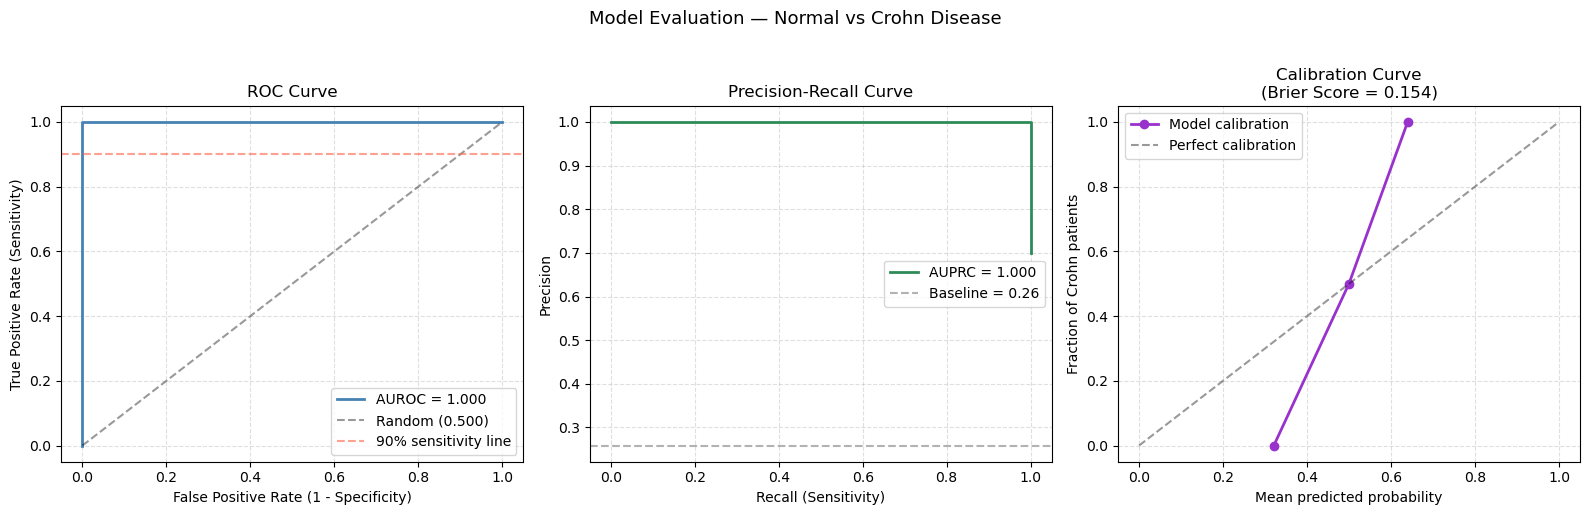

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── ROC Curve ─────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(all_labels, disease_probs)
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'AUROC = {auroc:.3f}')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4, label='Random (0.500)')
axes[0].axhline(y=0.9, color='tomato', linestyle='--',
                alpha=0.6, label='90% sensitivity line')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# ── Precision-Recall Curve ────────────────────────────────────
prec_arr, rec_arr, _ = precision_recall_curve(all_labels, disease_probs)
axes[1].plot(rec_arr, prec_arr, color='seagreen', linewidth=2,
             label=f'AUPRC = {auprc:.3f}')
axes[1].axhline(y=30/116, color='gray', linestyle='--',
                alpha=0.6, label=f'Baseline = {30/116:.2f}')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

# ── Calibration curve ─────────────────────────────────────────
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(
    all_labels, disease_probs, n_bins=5
)
axes[2].plot(prob_pred, prob_true,
             marker='o', color='darkorchid', linewidth=2,
             label='Model calibration')
axes[2].plot([0,1], [0,1], 'k--', alpha=0.4,
             label='Perfect calibration')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Fraction of Crohn patients')
axes[2].set_title(f'Calibration Curve\n(Brier Score = {brier:.3f})')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Model Evaluation — Normal vs Crohn Disease',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

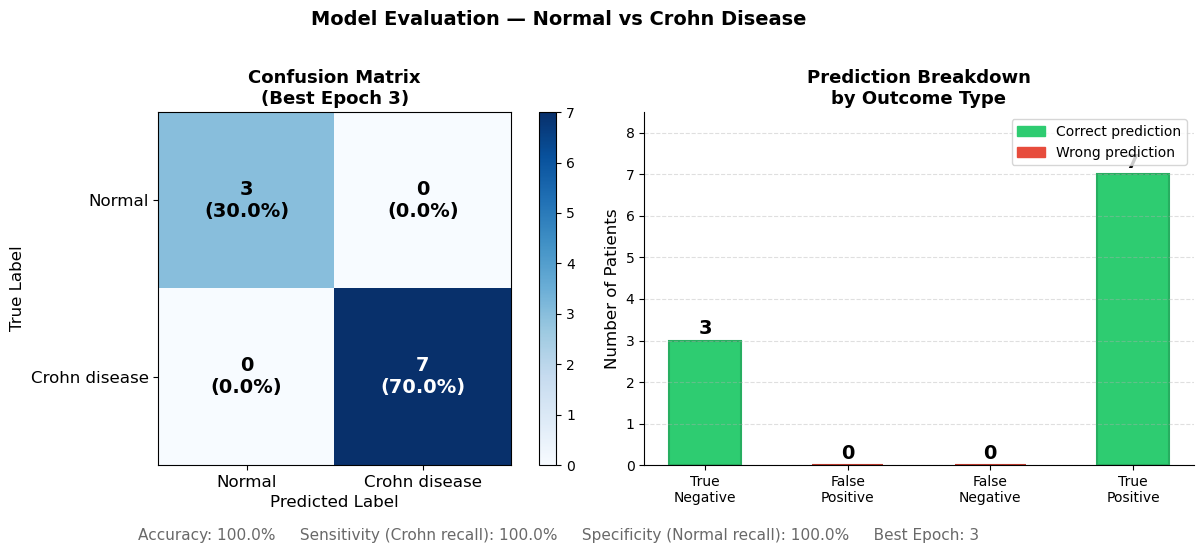

Saved → confusion_matrix.png ✓


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import confusion_matrix

# ── Load best model ────────────────────────────────────────────
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for Z, mask, labels in validation_loader:
        Z, mask, labels = (Z.to(DEVICE),
                           mask.to(DEVICE),
                           labels.to(DEVICE))
        Z = F.normalize(Z, dim=-1)

        preds, _, _ = model(Z, mask)
        all_preds.append(preds.argmax(1).cpu())
        all_labels.append(labels.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# ── Compute confusion matrix ───────────────────────────────────
cm             = confusion_matrix(all_labels, all_preds)
TN, FP, FN, TP = cm.ravel()

class_names = ["Normal", "Crohn disease"]

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Heatmap ──────────────────────────────────────────────
im = axes[0].imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=axes[0])

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(class_names, fontsize=12)
axes[0].set_yticklabels(class_names, fontsize=12)
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)
axes[0].set_title(
    f"Confusion Matrix\n(Best Epoch {best_epoch})",
    fontsize=13, fontweight="bold"
)

# Annotate each cell with count + percentage
total = len(all_labels)
for i in range(2):
    for j in range(2):
        count   = cm[i][j]
        percent = count / total * 100
        color   = "white" if cm[i][j] > cm.max() / 2 else "black"
        axes[0].text(
            j, i,
            f"{count}\n({percent:.1f}%)",
            ha="center", va="center",
            fontsize=14, fontweight="bold",
            color=color
        )

# ── Right: Per-class breakdown bar chart ───────────────────────
categories  = ["True\nNegative", "False\nPositive",
               "False\nNegative", "True\nPositive"]
values      = [TN, FP, FN, TP]
colors      = ["#2ecc71", "#e74c3c", "#e74c3c", "#2ecc71"]
edge_colors = ["#27ae60", "#c0392b", "#c0392b", "#27ae60"]

bars = axes[1].bar(
    categories, values,
    color=colors,
    edgecolor=edge_colors,
    linewidth=1.5,
    width=0.5
)

# Annotate bars with count
for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        str(val),
        ha="center", va="bottom",
        fontsize=14, fontweight="bold"
    )

axes[1].set_ylabel("Number of Patients", fontsize=12)
axes[1].set_title(
    "Prediction Breakdown\nby Outcome Type",
    fontsize=13, fontweight="bold"
)
axes[1].set_ylim(0, max(values) + 1.5)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# Legend
correct_patch = mpatches.Patch(color="#2ecc71", label="Correct prediction")
wrong_patch   = mpatches.Patch(color="#e74c3c", label="Wrong prediction")
axes[1].legend(
    handles=[correct_patch, wrong_patch],
    fontsize=10,
    loc="upper right"
)

# ── Metrics text below plots ───────────────────────────────────
sensitivity = TP / (TP + FN) * 100 if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) * 100 if (TN + FP) > 0 else 0
accuracy    = (TP + TN) / total * 100

fig.text(
    0.5, -0.04,
    f"Accuracy: {accuracy:.1f}%     "
    f"Sensitivity (Crohn recall): {sensitivity:.1f}%     "
    f"Specificity (Normal recall): {specificity:.1f}%     "
    f"Best Epoch: {best_epoch}",
    ha="center", fontsize=11,
    color="dimgray"
)

plt.suptitle(
    "Model Evaluation — Normal vs Crohn Disease",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig(
    "confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
print("Saved → confusion_matrix.png ✓")

### Building umap using patient embeddings

In [19]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


Total donors for UMAP : 50
  Discovery            : 40
  Validation           : 10
  Embedding shape      : (50, 512)


/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fitted ✓


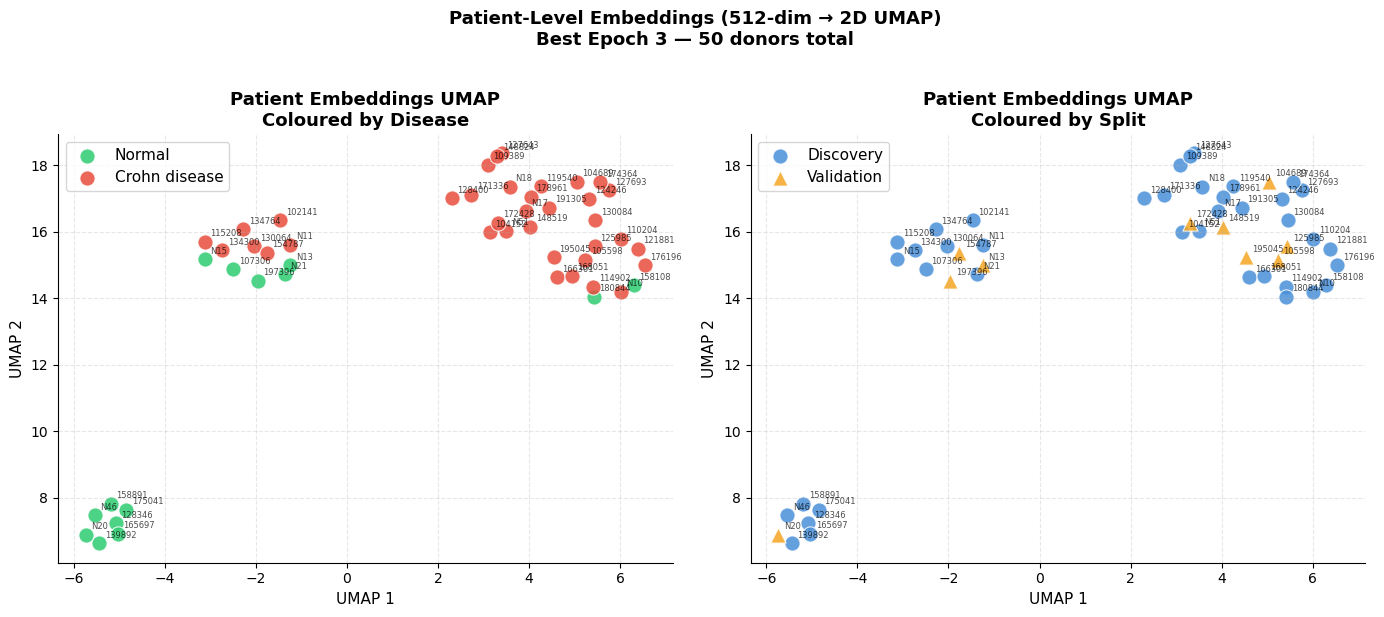

Saved → patient_umap.png ✓


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from umap import UMAP

# ── Load best model ────────────────────────────────────────────
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

all_patient_embs = []
all_labels       = []
all_donor_ids    = []

# ── Extract patient embeddings from validation set ─────────────
with torch.no_grad():
    for Z, mask, labels in validation_loader:
        Z, mask, labels = (Z.to(DEVICE),
                           mask.to(DEVICE),
                           labels.to(DEVICE))
        Z = F.normalize(Z, dim=-1)

        # ── patient_emb is (B, 512) — one vector per patient ──
        _, patient_emb, _ = model(Z, mask)

        all_patient_embs.append(patient_emb.cpu())
        all_labels.append(labels.cpu())

# ── Also extract from discovery set ───────────────────────────
# So UMAP shows all donors not just validation
disc_labels_arr = np.load(DISCOVERY_LABELS_PATH)
disc_files      = sorted([
    f for f in os.listdir(DISCOVERY_DIR) if f.endswith(".npy")
])

disc_donor_ids  = [f.replace("_embeddings.npy", "") for f in disc_files]
val_donor_ids   = [f.replace("_embeddings.npy", "") for f in val_files]

all_disc_embs   = []
all_disc_labels = []

with torch.no_grad():
    for Z, mask, labels in discovery_loader:
        Z, mask, labels = (Z.to(DEVICE),
                           mask.to(DEVICE),
                           labels.to(DEVICE))
        Z = F.normalize(Z, dim=-1)

        _, patient_emb, _ = model(Z, mask)

        all_disc_embs.append(patient_emb.cpu())
        all_disc_labels.append(labels.cpu())

# ── Concatenate discovery + validation ────────────────────────
disc_embs_np   = torch.cat(all_disc_embs).numpy()
disc_labels_np = torch.cat(all_disc_labels).numpy()

val_embs_np    = torch.cat(all_patient_embs).numpy()
val_labels_np  = torch.cat(all_labels).numpy()

all_embs_np    = np.concatenate([disc_embs_np,  val_embs_np],   axis=0)
all_labels_np  = np.concatenate([disc_labels_np, val_labels_np], axis=0)

# Track which donors are validation vs discovery for plotting
split_flags    = (["Discovery"] * len(disc_embs_np) +
                  ["Validation"] * len(val_embs_np))
all_donor_ids  = disc_donor_ids + val_donor_ids

print(f"Total donors for UMAP : {len(all_embs_np)}")
print(f"  Discovery            : {len(disc_embs_np)}")
print(f"  Validation           : {len(val_embs_np)}")
print(f"  Embedding shape      : {all_embs_np.shape}")

# ── Fit UMAP ───────────────────────────────────────────────────
reducer = UMAP(
    n_components  = 2,
    n_neighbors   = 5,      # small — dataset is only ~50 donors
    min_dist      = 0.3,
    random_state  = 42
)
embedding_2d = reducer.fit_transform(all_embs_np)   # (N_donors, 2)

print("UMAP fitted ✓")

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: coloured by disease label ───────────────────────────
color_map   = {0: "#2ecc71", 1: "#e74c3c"}
label_map_r = {0: "Normal", 1: "Crohn disease"}

for label_val in [0, 1]:
    idx = all_labels_np == label_val
    axes[0].scatter(
        embedding_2d[idx, 0],
        embedding_2d[idx, 1],
        c      = color_map[label_val],
        label  = label_map_r[label_val],
        s      = 120,
        alpha  = 0.85,
        edgecolors = "white",
        linewidths = 0.8
    )

# Annotate each donor point with donor_id
for i, did in enumerate(all_donor_ids):
    axes[0].annotate(
        did,
        (embedding_2d[i, 0], embedding_2d[i, 1]),
        fontsize   = 6,
        alpha      = 0.7,
        textcoords = "offset points",
        xytext     = (4, 4)
    )

axes[0].set_title(
    "Patient Embeddings UMAP\nColoured by Disease",
    fontsize=13, fontweight="bold"
)
axes[0].set_xlabel("UMAP 1", fontsize=11)
axes[0].set_ylabel("UMAP 2", fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.3)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# ── Right: coloured by split (discovery vs validation) ─────────
split_color_map = {"Discovery": "#4A90D9", "Validation": "#F5A623"}

for split in ["Discovery", "Validation"]:
    idx = np.array(split_flags) == split
    axes[1].scatter(
        embedding_2d[idx, 0],
        embedding_2d[idx, 1],
        c      = split_color_map[split],
        label  = split,
        s      = 120,
        alpha  = 0.85,
        edgecolors = "white",
        linewidths = 0.8,
        marker = "o" if split == "Discovery" else "^"
    )

# Annotate donor IDs
for i, did in enumerate(all_donor_ids):
    axes[1].annotate(
        did,
        (embedding_2d[i, 0], embedding_2d[i, 1]),
        fontsize   = 6,
        alpha      = 0.7,
        textcoords = "offset points",
        xytext     = (4, 4)
    )

axes[1].set_title(
    "Patient Embeddings UMAP\nColoured by Split",
    fontsize=13, fontweight="bold"
)
axes[1].set_xlabel("UMAP 1", fontsize=11)
axes[1].set_ylabel("UMAP 2", fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.3)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle(
    f"Patient-Level Embeddings (512-dim → 2D UMAP)\n"
    f"Best Epoch {best_epoch} — {len(all_embs_np)} donors total",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("patient_umap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → patient_umap.png ✓")

# Block x — Inference on a new patient

In [ ]:
def predict_new_patient(model, npy_path, label_names=None):
    """
    Runs inference on a single new patient .npy file.

    Args:
        model      : trained AttentionPoolingModel
        npy_path   : path to patient .npy file (num_cells, 512)
        label_names: list of class names e.g. ["Normal", "Crohn disease"]
    """
    if label_names is None:
        label_names = ["Normal", "Crohn disease"]

    model.eval()
    with torch.no_grad():

        Z    = torch.tensor(
                   np.load(npy_path),
                   dtype=torch.float32
               )
        mask = torch.ones(Z.shape[0], dtype=torch.bool)

        # Add batch dimension
        Z    = F.normalize(Z.unsqueeze(0), dim=-1)  # (1, num_cells, 512)
        mask = mask.unsqueeze(0)                     # (1, num_cells)

        Z, mask = Z.to(DEVICE), mask.to(DEVICE)

        preds, patient_emb, weights = model(Z, mask)
        probs = torch.softmax(preds, dim=1)

    print(f"Patient file   : {os.path.basename(npy_path)}")
    print(f"Cells          : {weights.shape[1]}")
    print("-" * 40)
    for i, name in enumerate(label_names):
        print(f"  {name:<20}: {probs[0][i]*100:.1f}%")
    pred_class = probs[0].argmax().item()
    print("-" * 40)
    print(f"  Prediction   : {label_names[pred_class]}")

    # Top 5 most attended cells
    top5 = weights[0].cpu().topk(5)
    print(f"\nTop 5 attended cell indices : {top5.indices.tolist()}")
    print(f"Their attention weights     : "
          f"{[round(w, 4) for w in top5.values.tolist()]}")

    return probs.cpu().numpy(), patient_emb.cpu().numpy(), weights.cpu().numpy()

# ── Example usage ──────────────────────────────────────────────
probs, emb, weights = predict_new_patient(
    model    = model,
    npy_path = "data/validation/P001_Normal_embeddings.npy"
)

AttributeError: 'PatientDataset' object has no attribute 'bag_paths'